In [ ]:
!pip install torch
!pip install transformers
!pip install datasets>=2.11
!pip install matplotlib
!pip install seaborn
!pip install pandas
!pip install umap-learn
!pip install boto3 --upgrade
!pip install numpy==1.23.5
!pip install -U sentence-transformers
!pip install transformers[torch]
!pip install ipympl

  Using cached numpy-1.23.5.tar.gz (10.7 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import datasets
import huggingface_hub
import matplotlib.font_manager as font_manager
import pandas as pd
import matplotlib.pyplot as plt
import transformers
import seaborn as sns
import pprint
from IPython.display import set_matplotlib_formats
from datasets import load_dataset

In [ ]:
emotions_dataset = load_dataset("dair-ai/emotion")
print(emotions_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [ ]:
emotions_dataset["train"]

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [ ]:
emotions_dataset["train"].features

{'text': Value('string'),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}

In [ ]:
emotions_dataset.set_format(type="pandas")
df = emotions_dataset["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [ ]:
df["label_name"] = df["label"].map(emotions_dataset["train"]
                              .features["label"].int2str)

df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Text(0.5, 1.0, 'Class Distributions')

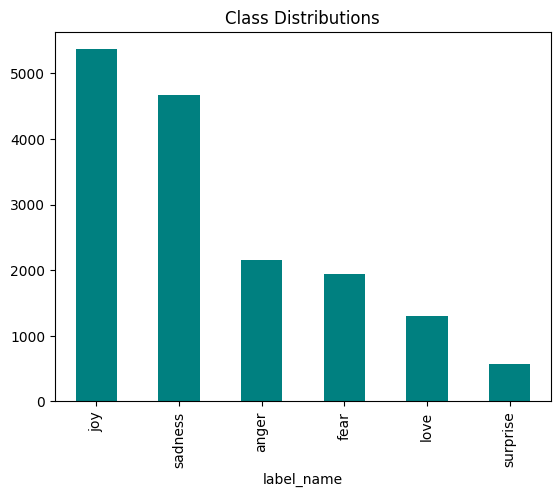

In [ ]:
df["label_name"].value_counts().plot(kind="bar", color="teal")
plt.title("Class Distributions")

In [ ]:
emotions_dataset.reset_format()

In [ ]:
from transformers import AutoTokenizer

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [ ]:
def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

pprint.pprint(tokenize(emotions_dataset["train"][167:169]), compact=True)

{'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
                    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]],
 'input_ids': [[101, 1045, 2031, 1037, 3110, 2026, 3193, 3475, 2102, 2183, 2000,
                2022, 2200, 2759, 1998, 2008, 2015, 2986, 102],
               [101, 1045, 2215, 2000, 2907, 2023, 3110, 1997, 7135, 15180,
                1998, 4687, 5091, 102, 0, 0, 0, 0, 0]],
 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]}


In [ ]:
encoded_emotions_ds = emotions_dataset.map(tokenize,
                                           batched=True, batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
pprint.pprint(encoded_emotions_ds["train"].features, compact=True)

{'attention_mask': List(Value('int8')),
 'input_ids': List(Value('int32')),
 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear',
                            'surprise']),
 'text': Value('string'),
 'token_type_ids': List(Value('int8'))}


In [ ]:
pprint.pprint(encoded_emotions_ds["train"][:2], compact=True)

{'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                     0, 0, 0, 0, 0, 0, 0],
                    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                     1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                     0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                     0, 0, 0, 0, 0, 0, 0]],
 'input_ids': [[101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0,
                0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                0, 0, 0, 0

In [ ]:
from transformers import AutoModel

model_checkpoint = "distilbert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoModel.from_pretrained(model_checkpoint).to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
!pip install --upgrade datasets

In [ ]:
def get_hidden_states(batch):
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}

    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

In [ ]:
encoded_emotions_ds.set_format("torch",
                    columns=["input_ids", "attention_mask", "label"])

hidden_emotions_ds = encoded_emotions_ds.map(get_hidden_states,
                                             batched=True,batch_size=64)

hidden_emotions_ds["train"].column_names

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

['text',
 'label',
 'input_ids',
 'token_type_ids',
 'attention_mask',
 'hidden_state']

In [ ]:
import numpy as np

X_train = np.array(hidden_emotions_ds["train"]["hidden_state"])
X_valid = np.array(hidden_emotions_ds["validation"]["hidden_state"])
y_train = np.array(hidden_emotions_ds["train"]["label"])
y_valid = np.array(hidden_emotions_ds["validation"]["label"])

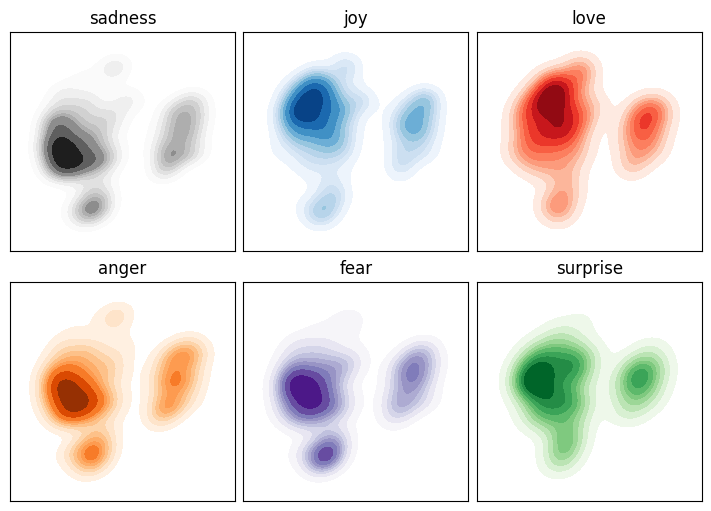

In [ ]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

X_scaled = MinMaxScaler().fit_transform(X_train)

mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
new_embed = pd.DataFrame(mapper.embedding_, columns=["X", "Y"]).assign(label=y_train)

fig, axes = plt.subplots(2, 3, figsize=(7, 5),
                         constrained_layout=True,
                         subplot_kw=dict(xticks=[], yticks=[], xlabel=None, ylabel=None))

axes = axes.flatten()

cmaps = ["Greys", "Blues", "Reds", "Oranges", "Purples", "Greens"]
labels = emotions_dataset["train"].features["label"].names

for label, cmap, ax in zip(labels, cmaps, axes):
    sns.kdeplot(data=new_embed.query(f"label=={labels.index(label)}"),
                x="X", y="Y", cmap=cmap, fill=True, ax=ax)

    ax.set_title(label)

plt.show()

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_labels = len(set(emotions_dataset["train"].features["label"].names))

model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels).to(device)

batch_size = 64
logging_steps = len(encoded_emotions_ds["train"]) // batch_size
model_name = f"DistilBERT-finetuned-on-emotion"

training_args = TrainingArguments(
    output_dir=model_name,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    disable_tqdm=False,
    logging_steps=logging_steps,
    push_to_hub=False
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1}

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=encoded_emotions_ds["train"],
    eval_dataset=encoded_emotions_ds["validation"],
    processing_class=tokenizer
)


trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.835693,0.325076,0.903000,0.901950
2,0.257829,0.223993,0.920500,0.920240


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.5467613372802734, metrics={'train_runtime': 267.4576, 'train_samples_per_second': 119.645, 'train_steps_per_second': 1.869, 'total_flos': 720342861696000.0, 'train_loss': 0.5467613372802734, 'epoch': 2.0})

In [ ]:
predicted_outputs = trainer.predict(encoded_emotions_ds["validation"])
predicted_outputs.metrics

{'test_loss': 0.22399337589740753,
 'test_accuracy': 0.9205,
 'test_f1': 0.9202395651589517,
 'test_runtime': 4.5551,
 'test_samples_per_second': 439.071,
 'test_steps_per_second': 7.025}

In [ ]:
y_preds = np.argmax(predicted_outputs.predictions, axis=1)

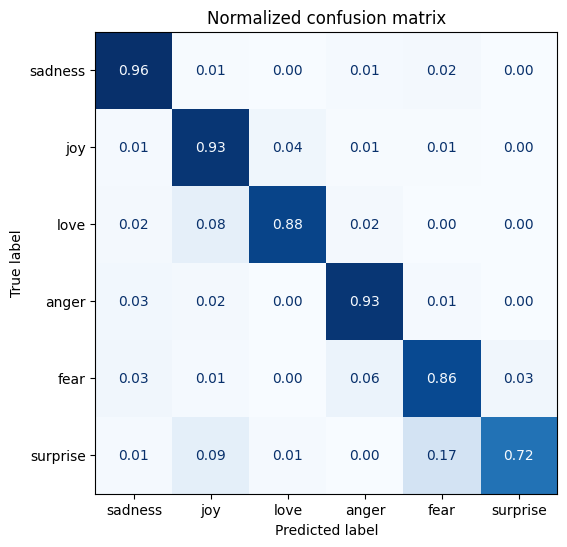

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()
plot_confusion_matrix(y_preds, y_valid, labels)

In [ ]:
from transformers import pipeline

model_path = "Rahmat82/DistilBERT-finetuned-on-emotion"
classifier = pipeline("text-classification", model=model_path)

config.json:   0%|          | 0.00/862 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
from transformers import pipeline

classifier = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)

def predict_emotion(custom_tweet):

    preds = classifier(custom_tweet)
    label_str = preds[0]['label']
    label_idx = int(label_str.replace('LABEL_', ''))

    labels_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
    emojis = ["😢", "😄", "😍", "😡", "😨", "😲"]

    return labels_names[label_idx], emojis[label_idx]

In [ ]:
my_text = "The gentle touch of your hand on mine is a silent promise that echoes through the corridors of my heart."

predicted_label, predicted_emoji = predict_emotion(my_text)
print(f"The predicted emotion for the text is: {predicted_label} {predicted_emoji}")
print("")

The predicted emotion for the text is: love 😍

